# AAI614: Data Science & its Applications

*Notebook 7.2: Accelerating Data Science*

<a href="https://colab.research.google.com/github/harmanani/AAI614/blob/main/Week%207/Notebook7.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Source: Data Science with Python and Dask

### Examining the Metadata of Dask Objects

You would need for this lab to downlaod the data and store on your local disk as it is arond 2GB with 42.3M Rows of Parking Ticket Data.  The data can be downloaded from [Kaggle](http://www.kaggle.com/new-york-city/nyc-parking-tickets/)

In [32]:
import dask.dataframe as dd
from dask.diagnostics import ProgressBar
from matplotlib import pyplot as plt
import kagglehub

# Download latest version if not already cached
path = kagglehub.dataset_download(
    "new-york-city/nyc-parking-tickets",
    force_download=False,
)

print("Path to dataset files:", path)
df = dd.read_csv(
    path + "/*.csv",
    dtype=str,
    low_memory=False,
)


Path to dataset files: /Users/saoud.haidar/.cache/kagglehub/datasets/new-york-city/nyc-parking-tickets/versions/2


In [33]:
# Compute the missing-value summary for each column.
missing_values = df.isnull().sum()
missing_values


Dask Series Structure:
npartitions=1
BBL               int64
Violation Time      ...
Dask Name: sum, 5 expressions
Expr=(~ NotNull(frame=ArrowStringConversion(frame=FromMapProjectable(6bb67f6)))).sum()

In [34]:
# Convert the missing-value counts to percentages.
missing_count = ((missing_values / df.index.size) * 100)
missing_count

Dask Series Structure:
npartitions=1
BBL               float64
Violation Time        ...
Dask Name: mul, 9 expressions
Expr=(~ NotNull(frame=ArrowStringConversion(frame=FromMapProjectable(6bb67f6)))).sum() / Index(frame=ArrowStringConversion(frame=FromMapProjectable(6bb67f6))).size() * 100

### Running Computations with the Compute Method

In [35]:
try:
    from dask.diagnostics import ProgressBar
except Exception:
    class ProgressBar:
        def __enter__(self):
            return self

        def __exit__(self, exc_type, exc_val, exc_tb):
            return False

with ProgressBar():
    missing_count_pct = missing_count.compute()
missing_count_pct


[########################################] | 100% Completed | 167.45 s


Summons Number                        0.000000
Plate ID                              0.020867
Registration State                    0.000000
Plate Type                            0.000000
Issue Date                            0.000000
Violation Code                        0.000000
Vehicle Body Type                     0.564922
Vehicle Make                          0.650526
Issuing Agency                        0.000000
Street Code1                          0.000000
Street Code2                          0.000000
Street Code3                          0.000000
Vehicle Expiration Date               0.000002
Violation Location                   15.142846
Violation Precinct                    0.000002
Issuer Precinct                       0.000002
Issuer Code                           0.000002
Issuer Command                       15.018851
Issuer Squad                         15.022566
Violation Time                        0.019207
Time First Observed                  90.040886
Violation Cou

In [36]:
try:
    from dask.diagnostics import ProgressBar
except Exception:
    class ProgressBar:
        def __enter__(self):
            return self

        def __exit__(self, exc_type, exc_val, exc_tb):
            return False

missing_count_pct = missing_count.compute()

columns_to_drop = (
    missing_count_pct[missing_count_pct > 60]
    .index
    .tolist()
)

with ProgressBar():
    df_dropped = df.drop(columns=columns_to_drop).persist()

df_dropped

[########################################] | 100% Completed | 164.17 s


,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,Street Code2,Street Code3,Vehicle Expiration Date,Violation Location,Violation Precinct,Issuer Precinct,Issuer Code,Issuer Command,Issuer Squad,Violation Time,Violation County,Violation In Front Of Or Opposite,House Number,Street Name,Date First Observed,Law Section,Sub Division,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Vehicle Year,Feet From Curb,Violation Post Code,Violation Description
npartitions=138,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


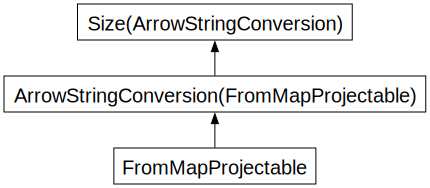

In [37]:
result = df.groupby("Violation County").size()

# Generate the task graph
result.visualize()

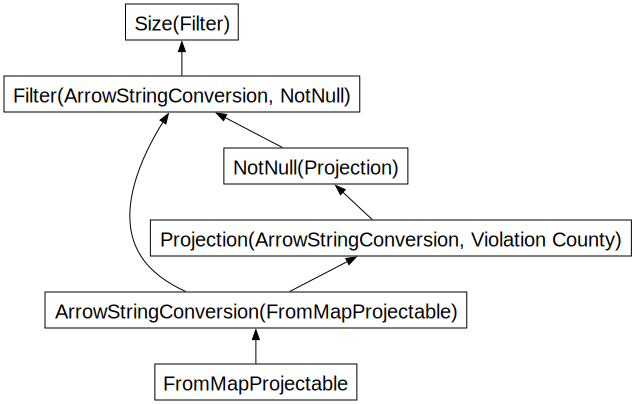

In [38]:
pipeline = (
    df[df["Violation County"].notnull()]
      .groupby("Violation County")
      .size()
)
pipeline.visualize()

In [39]:
from dask import delayed

@delayed
def compute_missing_percentages(frame):
    return (frame.isnull().sum() / frame.index.size) * 100

@delayed
def select_columns(percentages, threshold=60):
    return percentages[percentages > threshold].index

missing_pct_task = compute_missing_percentages(df)
columns_to_drop_task = select_columns(missing_pct_task, 60)

# Draw a smaller DAG that is easier to read
columns_to_drop_task.visualize(
    optimize_graph=True,
    filename="dag_example_small",
    format="png",
)


### Visualizing a Simple DAG using Dask Delayed Objects

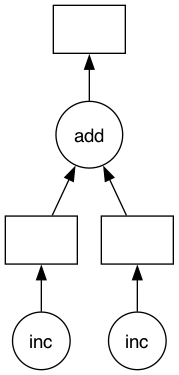

In [40]:
import dask.delayed as delayed
from dask.diagnostics import ProgressBar

def inc(i):
    return i + 1

def add(x, y):
    return x + y

x = delayed(inc)(1)
y = delayed(inc)(2)
z = delayed(add)(x, y)

z.visualize()

### Visualizing More Complex DAGs with Loops and Collections

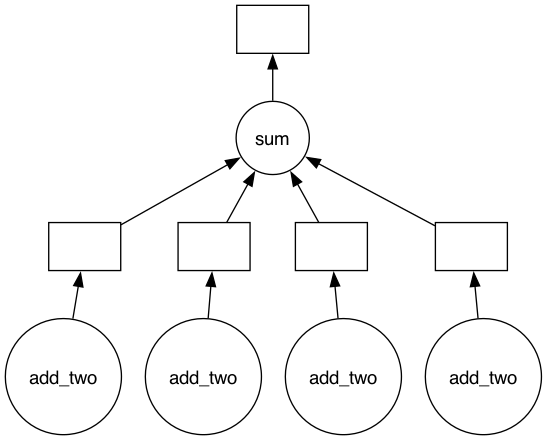

In [41]:
# Listing 2.7
def add_two(x):
    return x + 2

def sum_two_numbers(x,y):
    return x + y

def multiply_four(x):
    return x * 4

data = [1, 5, 8, 10]

step1 = [delayed(add_two)(i) for i in data]
total = delayed(sum)(step1)
total.visualize()

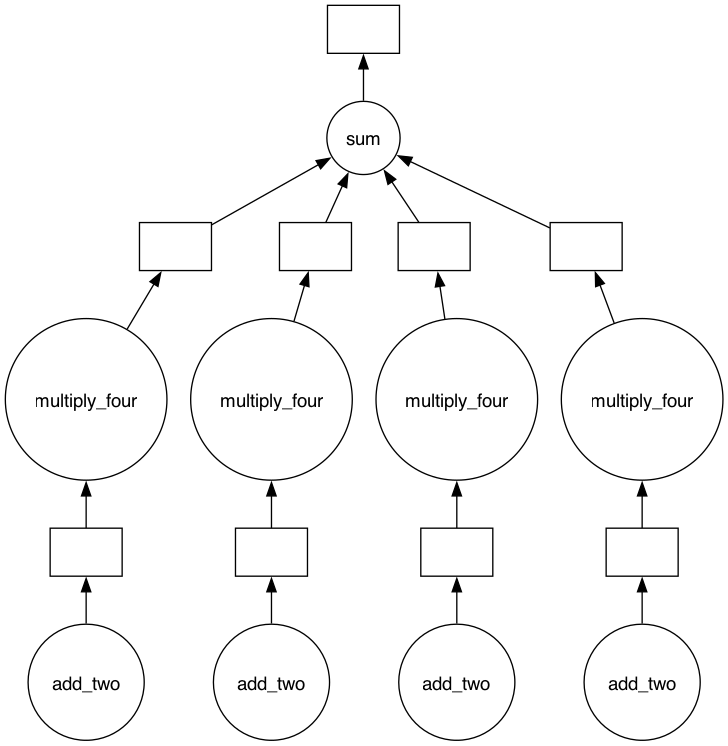

In [42]:
def add_two(x):
    return x + 2

def sum_two_numbers(x,y):
    return x + y

def multiply_four(x):
    return x * 4

data = [1, 5, 8, 10]

step1 = [delayed(add_two)(i) for i in data]
step2 = [delayed(multiply_four)(j) for j in step1]
total = delayed(sum)(step2)
total.visualize()

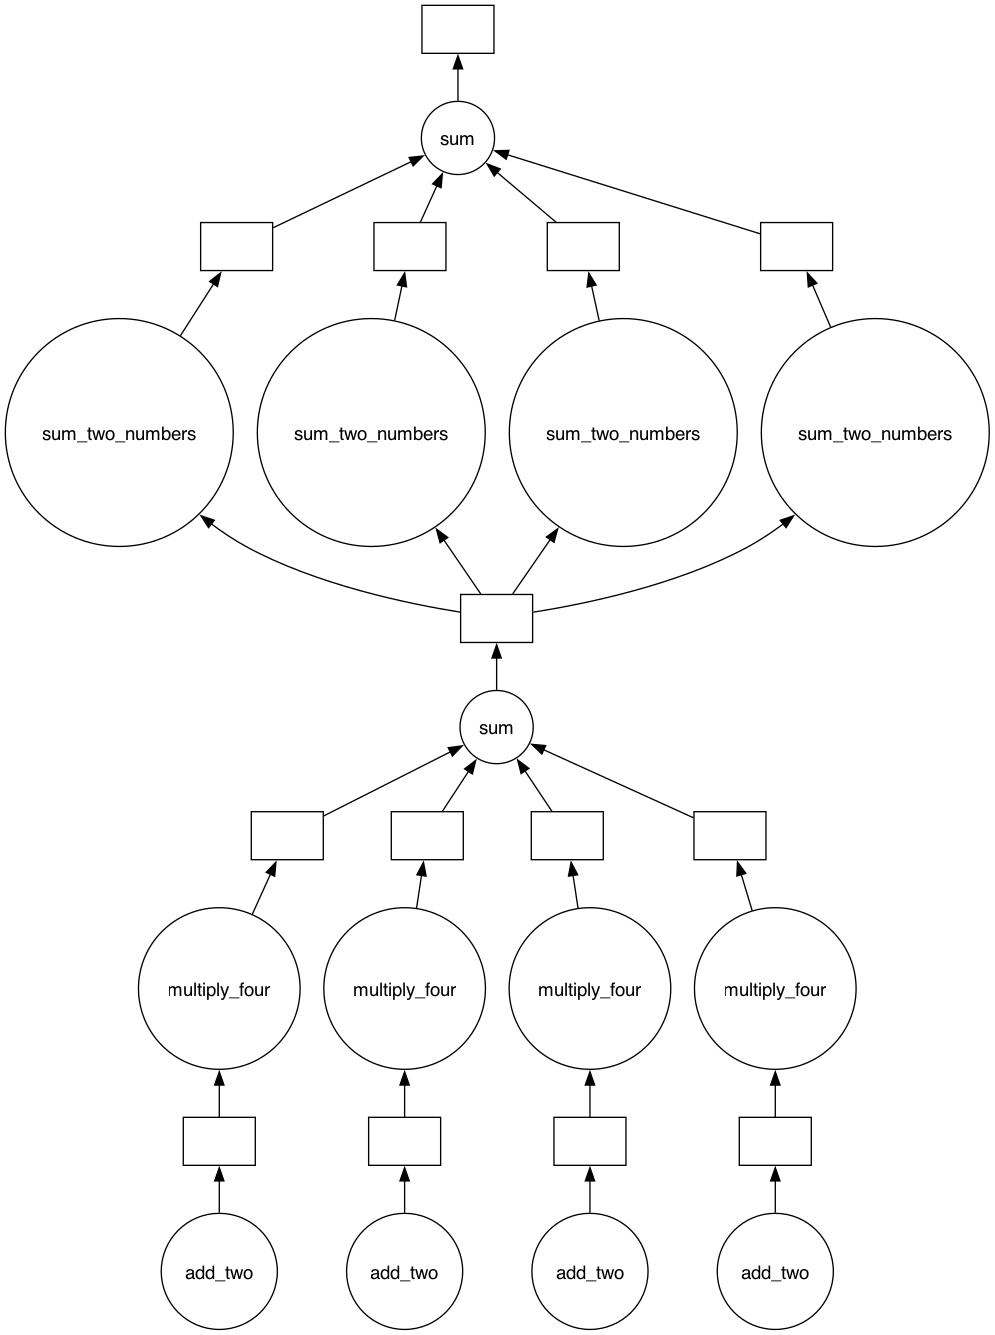

In [43]:
data2 = [delayed(sum_two_numbers)(k, total) for k in data]
total2 = delayed(sum)(data2)
total2.visualize()

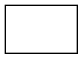

In [44]:
total_persisted = total.persist()
total_persisted.visualize()

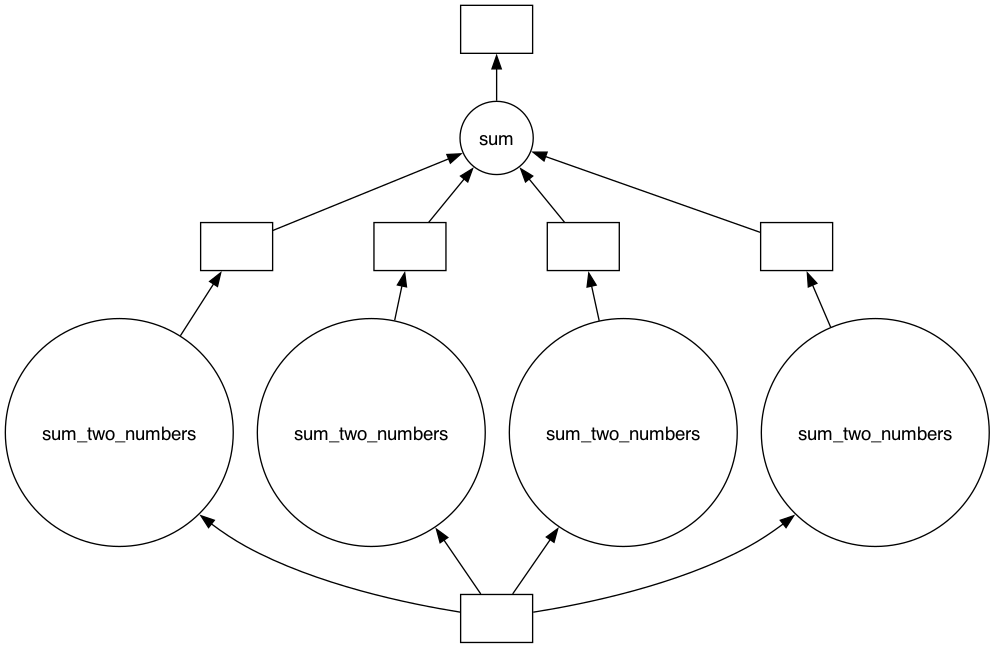

In [45]:
data2 = [delayed(sum_two_numbers)(l, total_persisted) for l in data]
total2 = delayed(sum)(data2)
total2.visualize()

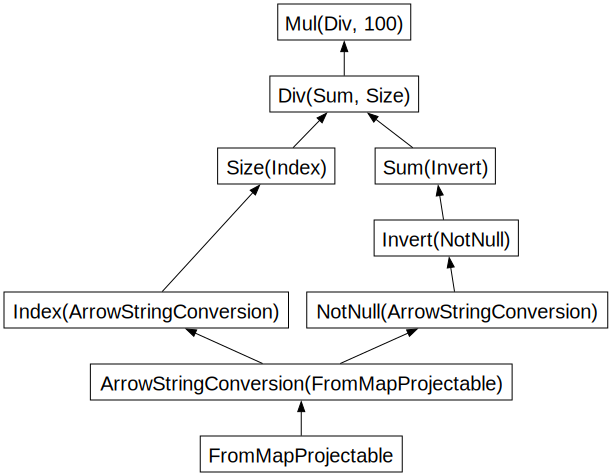

In [46]:
missing_count.visualize()

The NYC Parking dataset contains columns such as:

* Issue Date
* Violation County
* Registration State
* Vehicle Make
* Issuer Precinct
* Violation Code

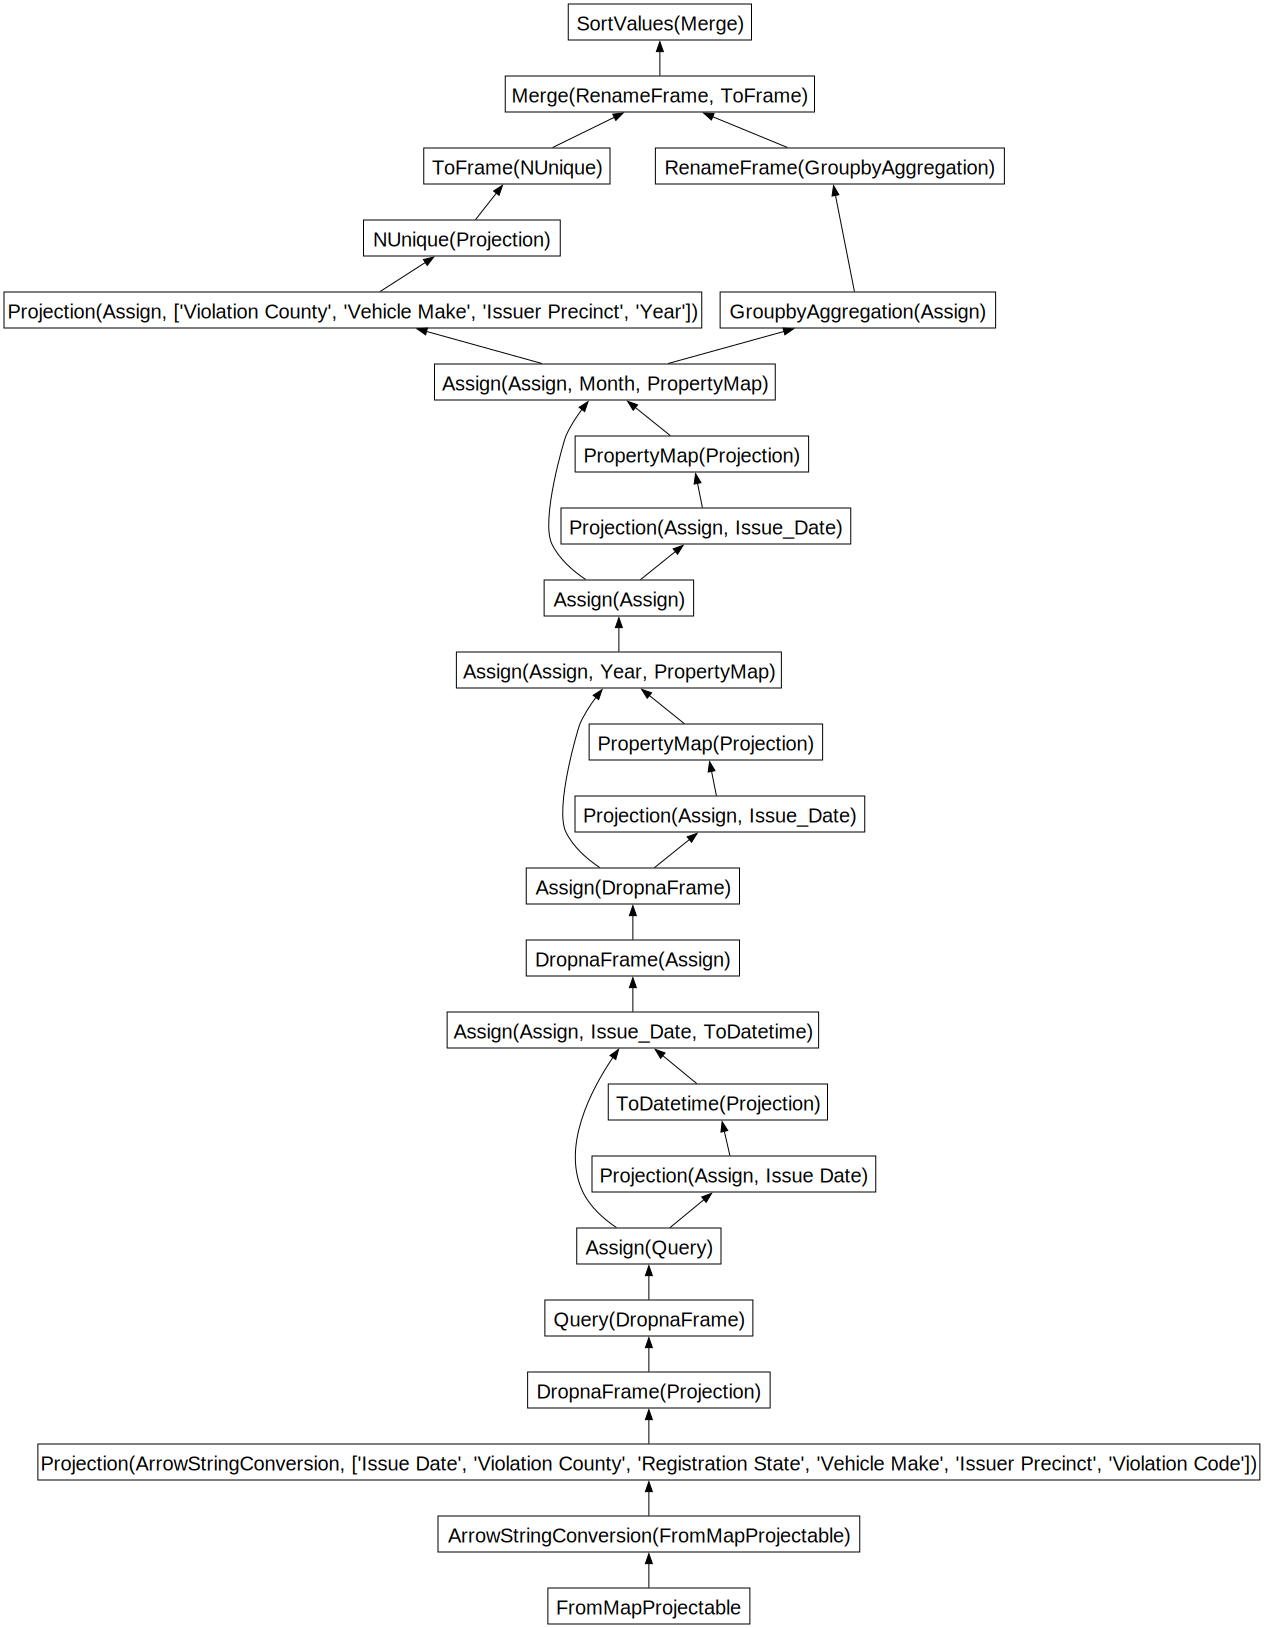

In [47]:
# select and prepare the relevant columns and date fields
selected = (
    df[
        [
            "Issue Date",
            "Violation County",
            "Registration State",
            "Vehicle Make",
            "Issuer Precinct",
            "Violation Code"
        ]
    ]
    .dropna(subset=["Violation County"])
    .query("`Registration State` == 'NY'")
    .assign(
        Issue_Date=lambda x: dd.to_datetime(x["Issue Date"], errors="coerce")
    )
    .dropna(subset=["Issue_Date"])
    .assign(
        Year=lambda x: x.Issue_Date.dt.year,
        Month=lambda x: x.Issue_Date.dt.month
    )
)

group_keys = ["Year", "Violation County", "Vehicle Make"]

# compute ticket counts
tickets = (
    selected
    .groupby(group_keys)
    .agg({"Violation Code": "count"})
    .rename(columns={"Violation Code": "Tickets"})
)

# compute number of unique precincts per group (nunique as a separate operation)
precincts = (
    selected
    .groupby(group_keys)["Issuer Precinct"]
    .nunique()
    .to_frame("Precincts")
)

# join the results and sort
pipeline = tickets.join(precincts).sort_values("Tickets", ascending=False)

pipeline.visualize()